## Import thư viện và khởi tạo OCR Engine

In [1]:
import sys
sys.path.insert(0, '..')

import os
import json
import glob
import matplotlib.pyplot as plt
from PIL import Image

from src.ocr.ocr_processor import PaddleOCRProcessor

# Khởi tạo OCR processor
ocr_processor = PaddleOCRProcessor(
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False
)

c:\Users\Thach\miniconda3\envs\project\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `DISABLE_MODEL_SOURCE_CHECK` to `True`.


Đang khởi tạo PaddleOCR engine...


c:\Users\Thach\miniconda3\envs\project\lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Thach\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('PP-OCRv5_server_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Thach\.paddlex\official_models\PP-OCRv5_server_rec`.


-> PaddleOCR đã sẵn sàng!


## Cấu hình đường dẫn

In [2]:
from src.utils.constant import *
from src.ocr.layout import *

Input folder: d:\Thach\HUST\Project_1\VQA\code\dataset\DocVQA_Images


## Chọn 1 ảnh mẫu

Chạy OCR với Layout Analysis...

KẾT QUẢ LAYOUT ANALYSIS
Số lines: 46
Số blocks: 16
Số regions: 10

Regions phát hiện:
--------------------------------------------------------------------------------

1. Type: FORM | Score: 1.000
   - Colon ratio: 1.00
   - Left alignment: 1.00
   - Right alignment: 0.00

2. Type: TEXT | Score: 1.000
   - Avg line length: 61.7
   - Spacing uniformity: 0.97

3. Type: TEXT | Score: 0.747
   - Avg line length: 51.4
   - Spacing uniformity: 0.98

4. Type: FORM | Score: 0.256
   - Colon ratio: 0.20
   - Left alignment: 0.98
   - Right alignment: 0.59

5. Type: TEXT | Score: 1.000
   - Avg line length: 57.7
   - Spacing uniformity: 0.98

6. Type: TEXT | Score: 0.749
   - Avg line length: 51.6
   - Spacing uniformity: 0.98

7. Type: FORM | Score: 0.227
   - Colon ratio: 0.14
   - Left alignment: 0.92
   - Right alignment: 0.65

8. Type: TEXT | Score: 0.723
   - Avg line length: 46.0
   - Spacing uniformity: 0.99

9. Type: TEXT | Score: 1.000
   - Avg line len

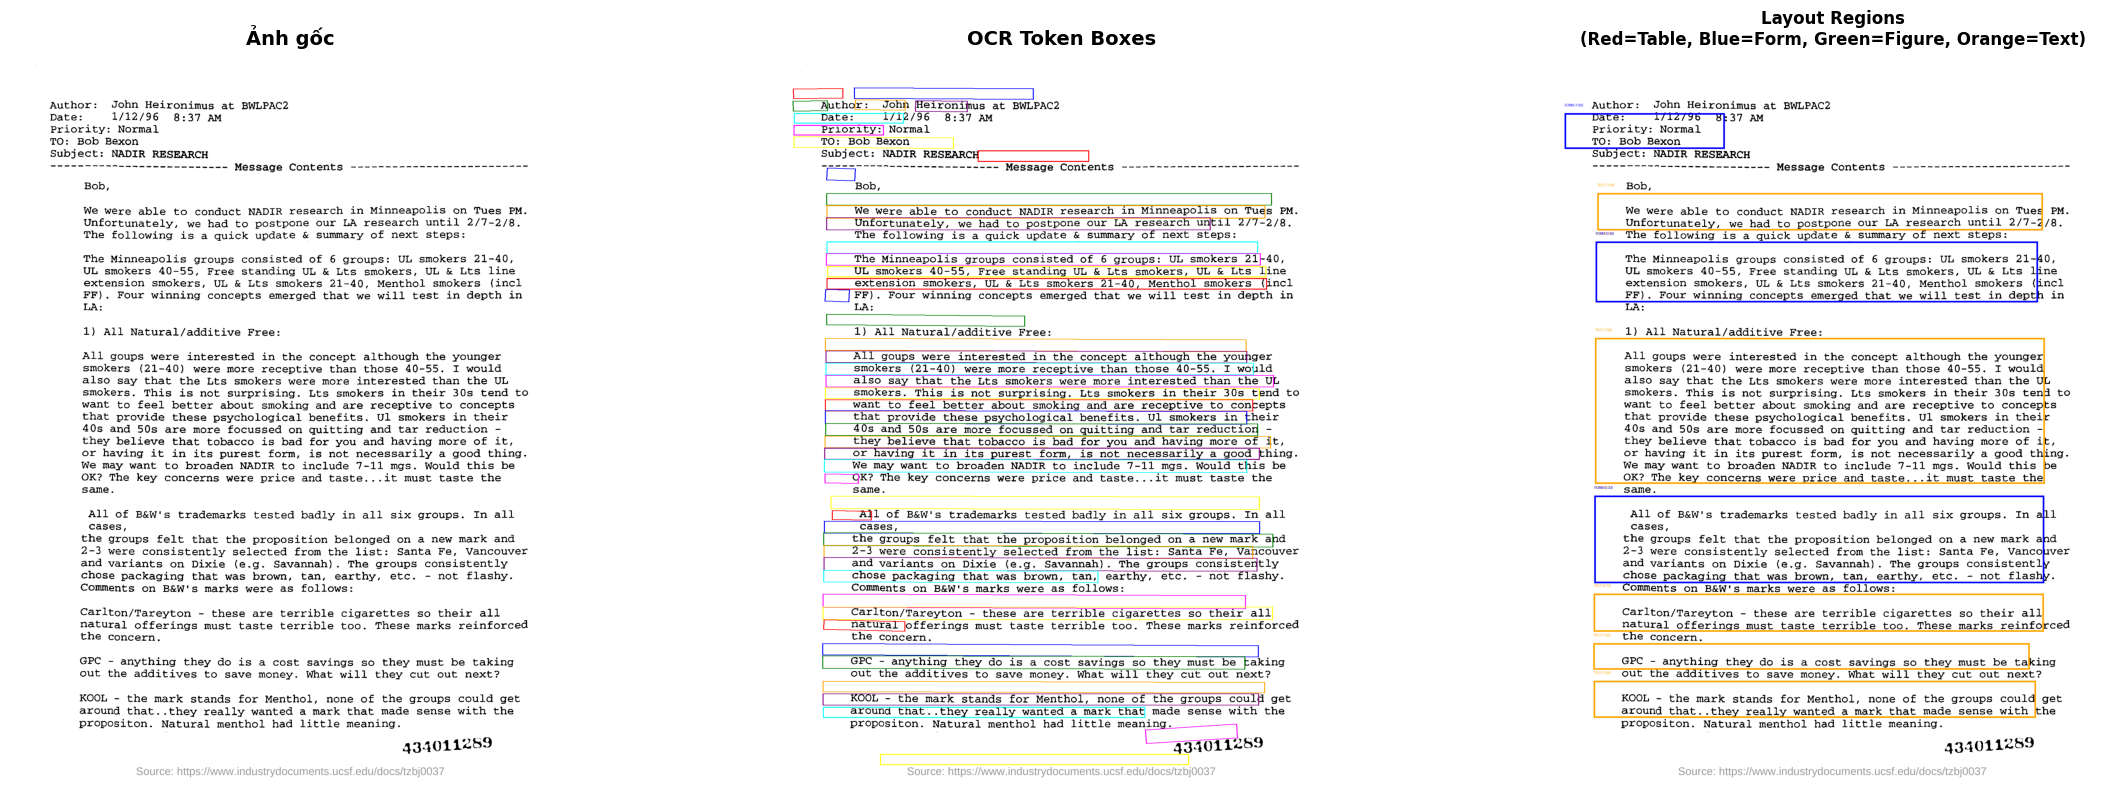


LEGEND - Region Colors:
  🔴 RED    = Table (bảng)
  🔵 BLUE   = Form (key:value)
  🟢 GREEN  = Figure (chart/plot)
  🟠 ORANGE = Text (đoạn văn)
  🟣 PURPLE = Layout (multi-column/heading)

TEXT CONTENT THEO TỪNG REGION

────────────────────────────────────────────────────────────────────────────────
📋 FORM REGIONS (3 phát hiện)
────────────────────────────────────────────────────────────────────────────────

[FORM #1] Score: 1.000
────────────────────────────────────────
✓ Key:Value Pattern Detected (100.0%)
────────────────────────────────────────
 1. Priority: Normal
 2. TO: Bob Bexon
 3. SubjeCt: NADIR RESEARCH

[FORM #2] Score: 0.256
────────────────────────────────────────
 1. The Minneapolis groups consisted of 6 groups: UL smokers 21-40,
 2. UL Smokers 4O-55, Free Standing UL & Lts Smokers, UL & Lts line
 3. extension smokers, UL & Lts smokers 21-40, Menthol smokers (incl
 4. FF). Four winning concepts emerged that we will test in depth in
 5. LA:

[FORM #3] Score: 0.227
─────────

In [3]:
# Tìm 1 ảnh mẫu
import random

sample_image = '../dataset/DocVQA_Images/test/250.png'
idx = random.randint(0, 1000)
if sample_image is None:
    for subset in SUBSETS:
        subset_folder = os.path.join(IMAGES_FOLDER, subset)
        if os.path.exists(subset_folder):
            images = glob.glob(os.path.join(subset_folder, "*.png"))[idx:idx+1]
            print(images)
            if images:
                sample_image = images[0]
                break
else:
    images = os.path.join(IMAGES_FOLDER, 'test', f'{sample_image}.png')
    
group(sample_image, ocr_processor)

---
## Document Layout Analysis

Phân tích cấu trúc document sau khi OCR:
- **Stage I**: Group token → line → block
- **Stage II**: Detect regions (table, form, figure, text, layout)

## Visualize Stage I Groups

Hiển thị các bước grouping ở Stage I:
- **Token**: Các bounding box từ OCR
- **Line**: Gộp tokens thành lines
- **Block**: Gộp lines thành blocks

Chạy OCR với Layout Analysis...


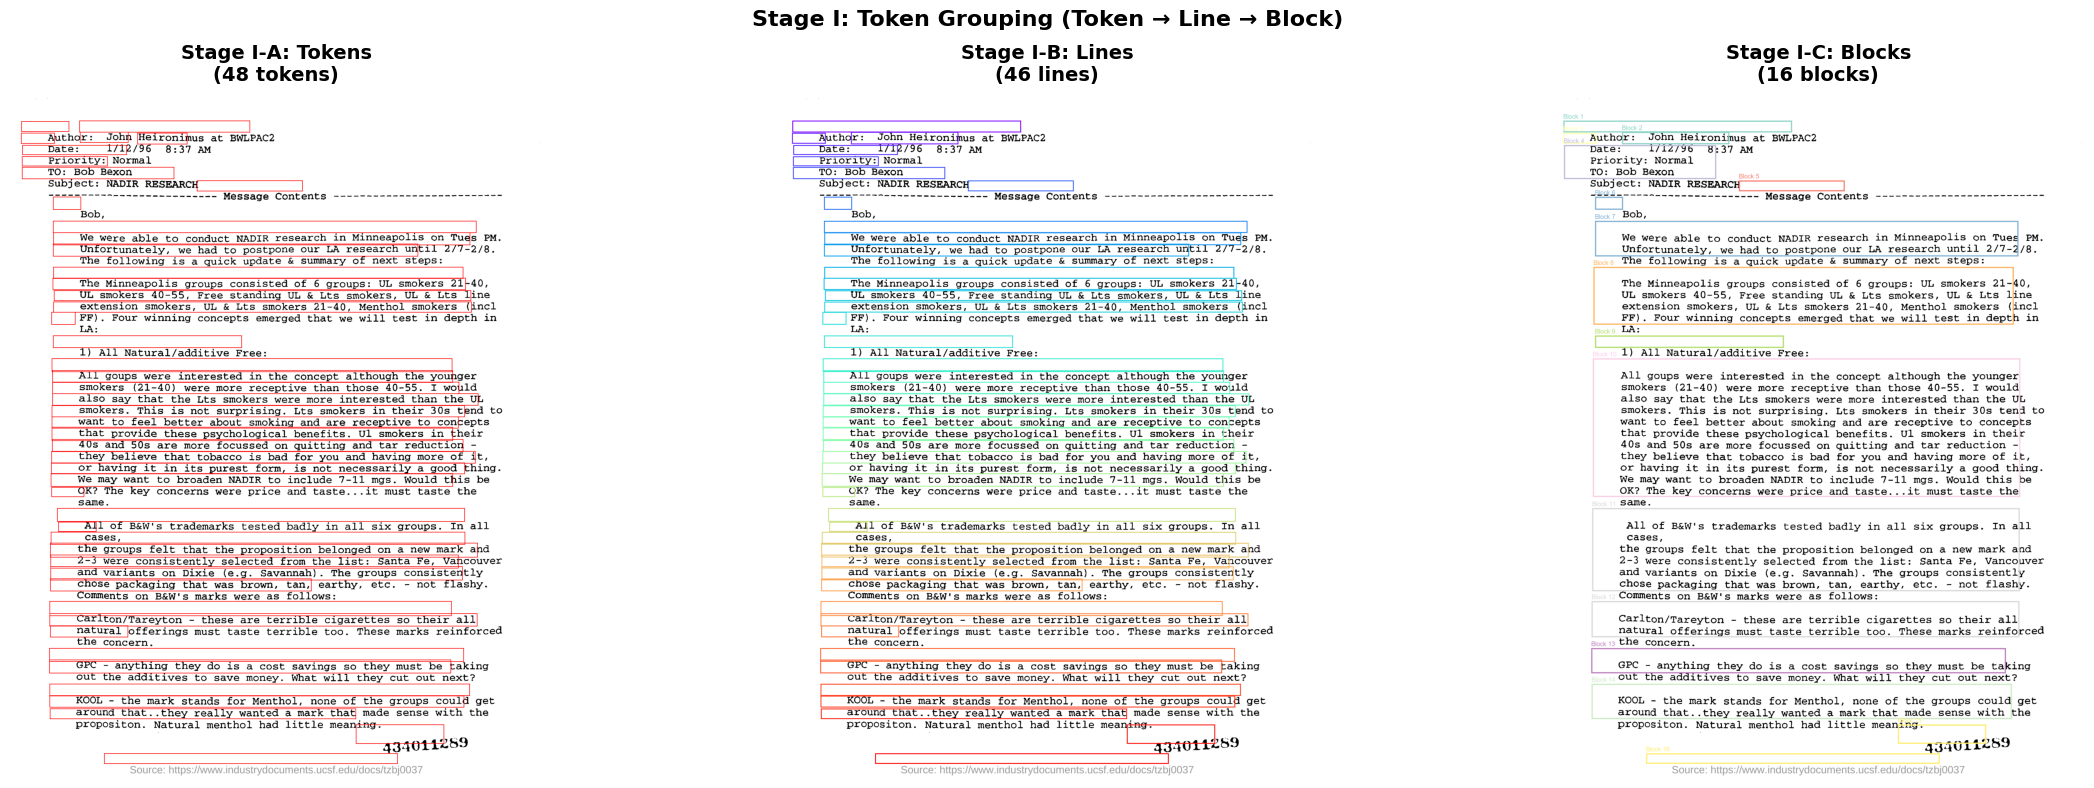


STAGE I - TOKEN GROUPING STATISTICS
Tokens: 48
Lines:  46
Blocks: 16



{'text': "Author: John Heironimus at BWLPAC2 Date: 1/12/96 8:37 AM Priority: Normal TO: Bob Bexon SubjeCt: NADIR RESEARCH Message Contents Bob, We were able to conduct NADIR research in Minneapolis on Tues PM. Unfortunately, we had to postpone our LA research until 2/7-2/8. The following is a quick update & summary of next steps: The Minneapolis groups consisted of 6 groups: UL smokers 21-40, UL Smokers 4O-55, Free Standing UL & Lts Smokers, UL & Lts line extension smokers, UL & Lts smokers 21-40, Menthol smokers (incl FF). Four winning concepts emerged that we will test in depth in LA: 1) All Natural/additive Free: All goups were interested in the concept although the younger smokers (21-40) were more receptive than those 40-55. I would also say that the Lts smokers were more interested than the UL smokers. This is not surprising. Lts smokers in their 3Os tend to want to feel better about smoking and are receptive to concepts that provide these psychological benefits. Ul smokers in th

In [4]:
visualize_stage1_groups(sample_image, ocr_processor)

---
## Semantic Layout Graph Visualization

Build and visualize semantic layout graph from detected regions

### Import Graph Visualization Utilities

In [5]:
from src.graph.graph_builder import GraphBuilder
from src.utils.graph_viz import *

print("✅ Graph visualization utilities imported")

✅ Graph visualization utilities imported


### Build Semantic Layout Graph

In [6]:
# Configure graph builder
graph_builder = GraphBuilder(
    iou_threshold=0.1,
    distance_threshold=200.0,
    projection_threshold=0.3,
    max_neighbors=5,
    min_edge_score=0.2
)

# Get regions from OCR result
ocr_result = ocr_processor.run_ocr_with_layout(
    sample_image,
    use_preprocessing=True,
    max_size=2500
)

if ocr_result.get('success') and ocr_result.get('layout'):
    regions = ocr_result['layout'].get('regions', [])
    
    # Build the graph
    graph_result = graph_builder.build_graph(regions)
    
    nodes = graph_result['nodes']
    edges = graph_result['edges']
    adjacency = graph_result['adjacency']
    
    print(f"\n{'='*60}")
    print(f"📊 GRAPH BUILDING RESULTS")
    print(f"{'='*60}")
    print(f"Total Nodes: {len(nodes)}")
    print(f"Total Edges: {len(edges)}")
    
    # Group edges by relation type
    relation_counts = {}
    for edge in edges:
        rel_type = edge['relation']
        relation_counts[rel_type] = relation_counts.get(rel_type, 0) + 1
    
    print(f"\nEdges by Relation Type:")
    print(f"-" * 60)
    for rel_type, count in sorted(relation_counts.items(), key=lambda x: x[1], reverse=True):
        print(f"  {rel_type:20s}: {count:3d} edges")
    
    # Group by category
    category_counts = {}
    for edge in edges:
        cat = edge.get('category', 'unknown')
        category_counts[cat] = category_counts.get(cat, 0) + 1
    
    print(f"\nEdges by Category:")
    print(f"-" * 60)
    for cat, count in sorted(category_counts.items(), key=lambda x: x[1], reverse=True):
        print(f"  {cat:15s}: {count:3d} edges")
    
    print(f"{'='*60}\n")
else:
    print("❌ Failed to get layout regions")
    regions = []
    nodes = []
    edges = []


📊 GRAPH BUILDING RESULTS
Total Nodes: 10
Total Edges: 50

Edges by Relation Type:
------------------------------------------------------------
  above               :  24 edges
  below               :  22 edges
  nearest_neighbor    :   4 edges

Edges by Category:
------------------------------------------------------------
  spatial        :  46 edges
  proximity      :   4 edges



### Visualize Graph - All Nodes and Edges

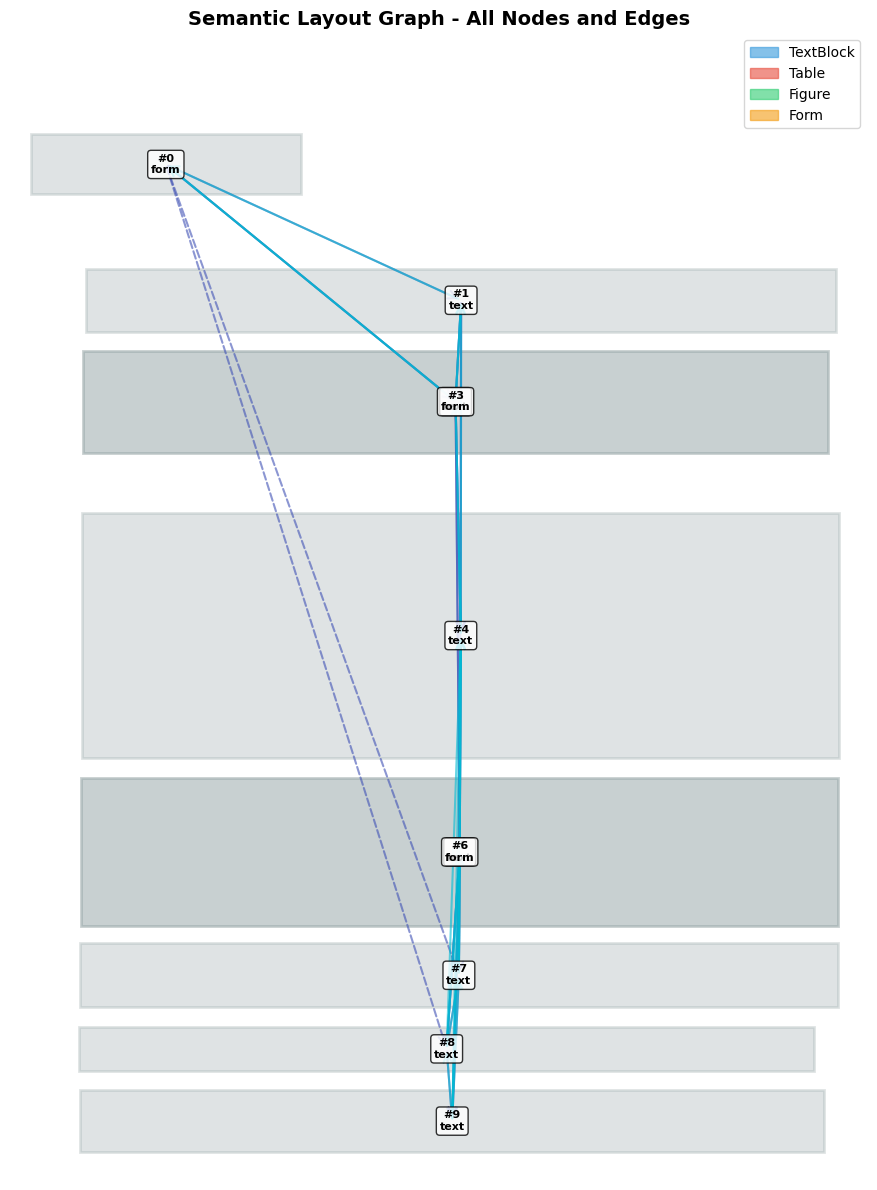

In [7]:
if nodes and edges:
    visualize_graph_basic(nodes, edges, figsize=(16, 12))
else:
    print("⚠️ No graph to visualize")

### Visualize by Relation Type

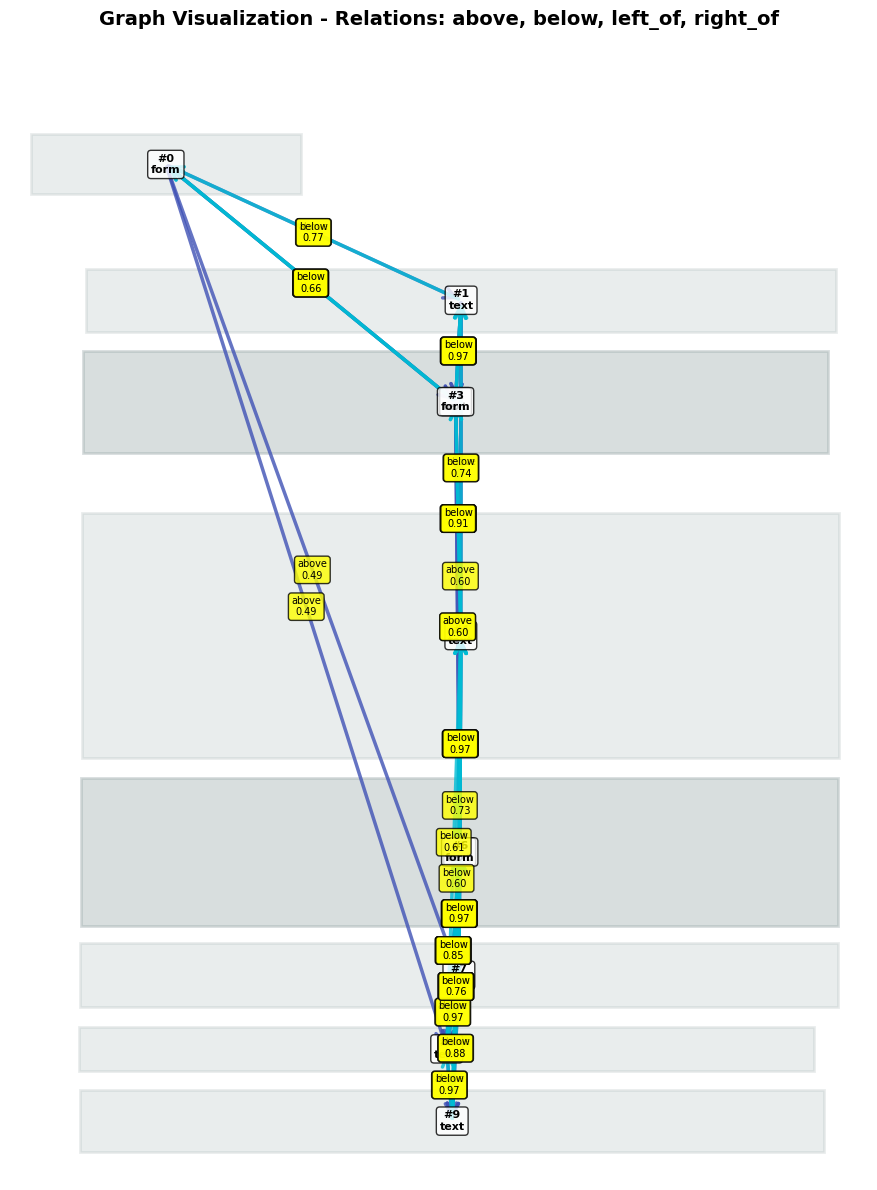

Showing 46 edges of type(s): ['above', 'below', 'left_of', 'right_of']


In [8]:
if nodes and edges:
    # Visualize spatial relations
    visualize_by_relation_type(nodes, edges, ['above', 'below', 'left_of', 'right_of'], figsize=(16, 12))
else:
    print("⚠️ No graph to visualize")

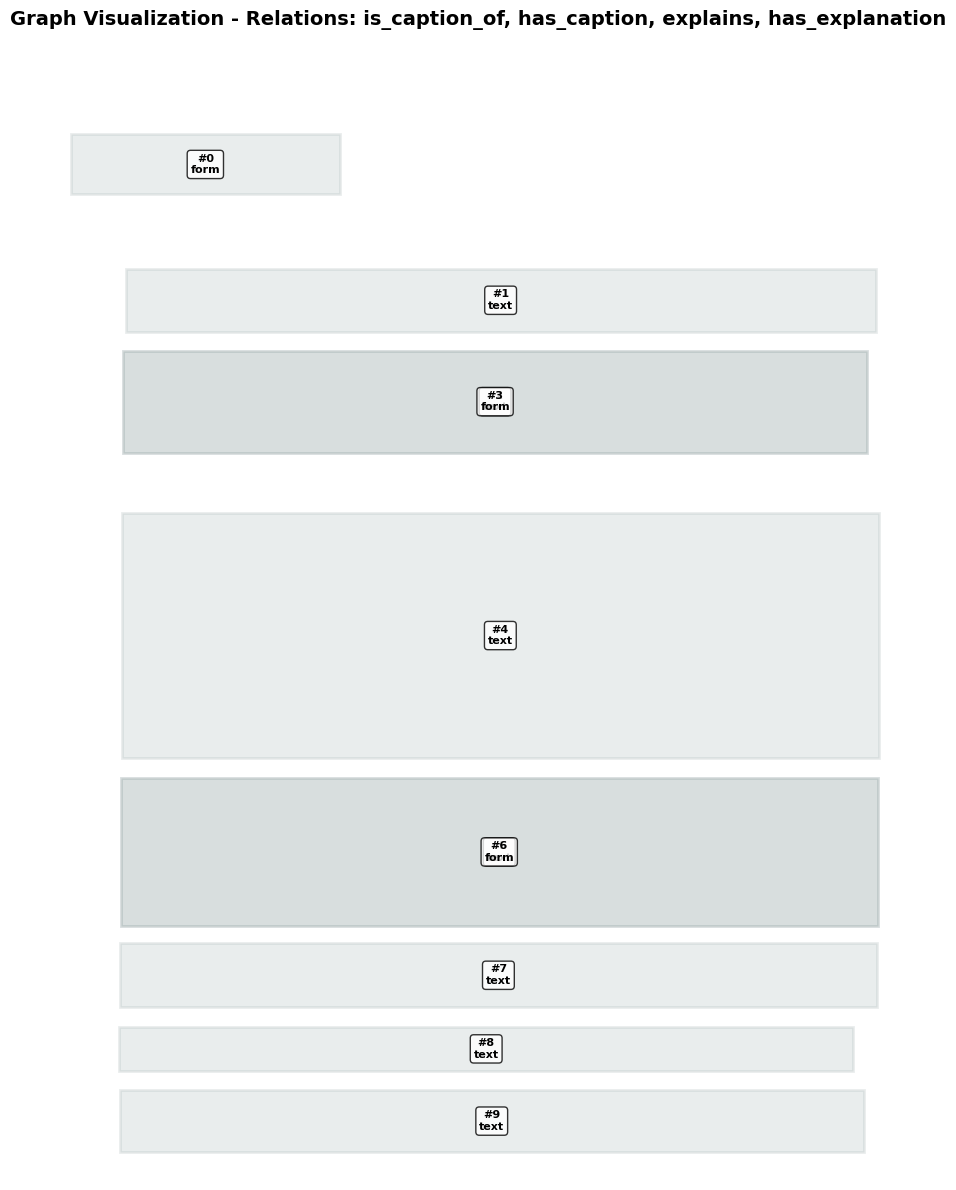

Showing 0 edges of type(s): ['is_caption_of', 'has_caption', 'explains', 'has_explanation']


In [9]:
if nodes and edges:
    # Visualize semantic relations
    visualize_by_relation_type(nodes, edges, ['is_caption_of', 'has_caption', 'explains', 'has_explanation'], figsize=(16, 12))
else:
    print("⚠️ No graph to visualize")

### Graph Statistics and Analysis


TOP 10 EDGES BY SCORE

 1. [nearest_neighbor] Score: 1.000 (proximity)
    Source #2 (text): The Minneapolis groups consisted of 6 groups: UL s...
    Target #3 (form): The Minneapolis groups consisted of 6 groups: UL s...

 2. [nearest_neighbor] Score: 1.000 (proximity)
    Source #3 (form): The Minneapolis groups consisted of 6 groups: UL s...
    Target #2 (text): The Minneapolis groups consisted of 6 groups: UL s...

 3. [nearest_neighbor] Score: 1.000 (proximity)
    Source #5 (text): All of B&W's trademarks tested badly in all six gr...
    Target #6 (form): All of B&W's trademarks tested badly in all six gr...

 4. [nearest_neighbor] Score: 1.000 (proximity)
    Source #6 (form): All of B&W's trademarks tested badly in all six gr...
    Target #5 (text): All of B&W's trademarks tested badly in all six gr...

 5. [above] Score: 0.974 (spatial)
    Source #5 (text): All of B&W's trademarks tested badly in all six gr...
    Target #7 (text): Carlton/Tareyton - these are terrible c

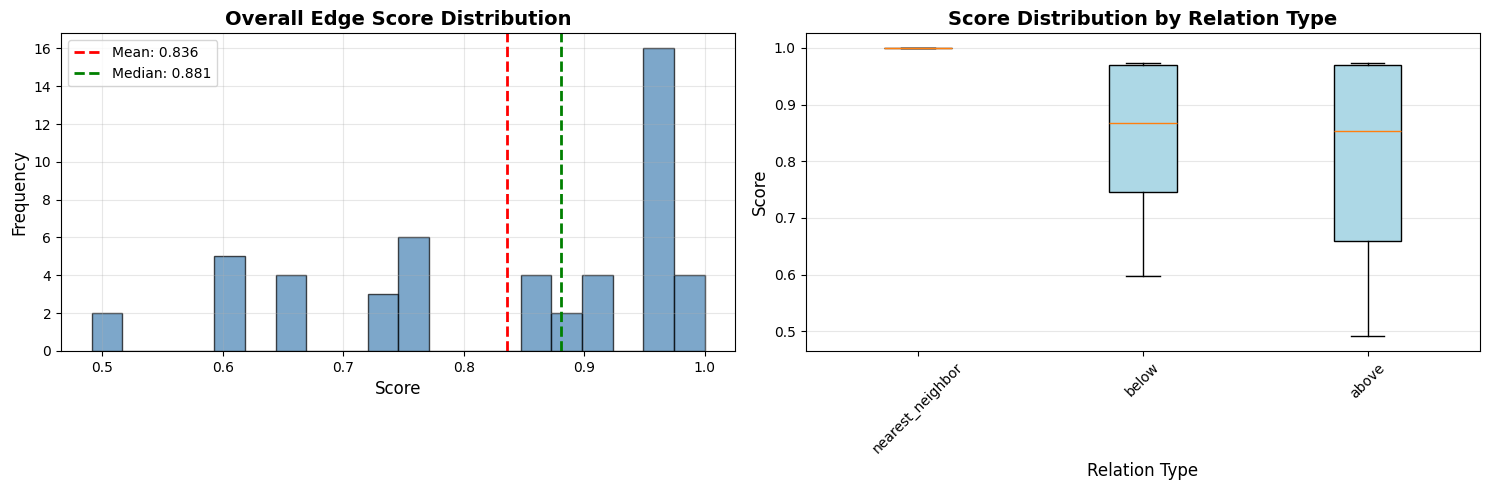

In [10]:
if nodes and edges:
    # Print detailed edge information
    print_edge_details(nodes, edges, top_n=10)
    
    # Analyze statistics
    analyze_graph_statistics(nodes, edges)
    
    # Plot score distributions
    plot_score_distributions(edges)
else:
    print("⚠️ No graph to analyze")

### Export Graph to JSON

In [11]:
if nodes and edges:
    import os
    output_path = os.path.join('..', 'output', 'graph_visualization_output.json')
    
    export_graph_to_json(
        graph_result=graph_result,
        output_path=output_path,
        metadata={
            'source_image': os.path.basename(sample_image),
            'num_regions': len(regions),
            'num_nodes': len(nodes),
            'num_edges': len(edges)
        }
    )
else:
    print("⚠️ No graph to export")

✅ Graph exported to: ..\output\graph_visualization_output.json

Exported data structure:
  - Nodes: 10
  - Edges: 50
  - Adjacency entries: 10
